# Outfit Compatiblity Rater


In [ ]:
# %pip install -r requirements.txt

In [25]:
%matplotlib inline

import numpy as np
import matplotlib.pylab as plt
import json
import os
from PIL import Image  
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.models import Model

#### Load all data files

In [ ]:
# Compatibility labels
with open('polyvore/fashion_compatibility_prediction.txt', 'r') as f:
    lines = f.readlines()
    
# Load and combine JSON files
with open('polyvore/train_no_dup.json', 'r') as f:
    train_data = json.load(f)
with open('polyvore/test_no_dup.json', 'r') as f:
    test_data = json.load(f)
with open('polyvore/valid_no_dup.json', 'r') as f:
    valid_data = json.load(f)

all_outfits = train_data + test_data + valid_data

#### Build lookup tables

In [ ]:
# Image lookup 
image_lookup = {}

for category in os.listdir('images/Re-PolyVore'):
    category_path = f'images/Re-PolyVore/{category}'
    if os.path.isdir(category_path):
        for filename in os.listdir(category_path):
            if filename.endswith('.jpg'):
                item_id = filename.replace('.jpg', '')
                image_lookup[item_id] = f'{category_path}/{filename}'

# Name lookup
name_lookup = {}
for outfit in all_outfits:
    set_id = outfit['set_id']
    for item in outfit['items']:
        item_id = f"{set_id}_{item['index']}"
        name_lookup[item_id] = item['name']

#### Display example outfit

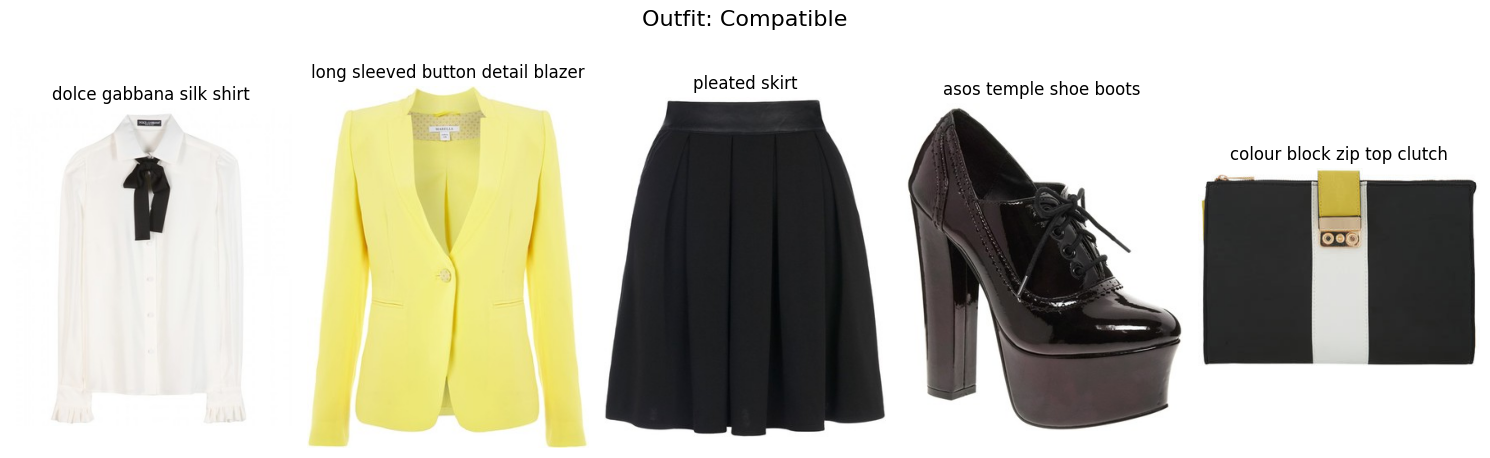

In [24]:
first_outfit = lines[0].strip().split()
label = first_outfit[0]
items = first_outfit[1:]

fig, axes = plt.subplots(1, len(items), figsize=(15, 5))

for i, item_id in enumerate(items):
    if item_id in image_lookup:
        img = Image.open(image_lookup[item_id])
        axes[i].imshow(img)
        name = name_lookup.get(item_id, 'Unknown')
        axes[i].set_title(name, fontsize=12, wrap=True)
        axes[i].axis('off')
    else:
        print(f"Missing: {item_id}")

label_text = "Compatible" if label == '1' else "Incompatible"
plt.suptitle(f"Outfit: {label_text}", fontsize=16)
plt.tight_layout()
plt.show()

#### Transfer Learning

In [31]:
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

In [ ]:
def get_embedding(item_id):
    img_path = image_lookup[item_id]
    
    img = keras_image.load_img(img_path, target_size=(224, 224))
    
    img_array = keras_image.img_to_array(img)
    
    img_array = np.expand_dims(img_array, axis=0)
    
    img_array = preprocess_input(img_array)
    
    embedding = base_model.predict(img_array, verbose=0)
    
    return embedding[0]

def get_outfit_embedding(item_ids):
    embeddings = []
    
    for item_id in item_ids:
        if item_id in image_lookup:
            embedding = get_embedding(item_id)
            embeddings.append(embedding)
    
    if len(embeddings) == 0:
        return None
    
    outfit_embedding = np.mean(embeddings, axis=0)
    return outfit_embedding

In [ ]:
# Process all outfits into embeddings
X = []  
y = []  

for i, line in enumerate(lines):
    parts = line.strip().split()
    label = int(parts[0])
    item_ids = parts[1:]
    
    outfit_vec = get_outfit_embedding(item_ids)
    
    if outfit_vec is not None:
        X.append(outfit_vec)
        y.append(label)
    
    # print progress every 500 outfits
    if i % 500 == 0:
        print(f"Processed {i}/{len(lines)} outfits...")

X = np.array(X)
y = np.array(y)

print(f"Done!")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Compatible outfits: {sum(y == 1)}")
print(f"Incompatible outfits: {sum(y == 0)}")